In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

DATA_PATH = Path(r"d:\Rhombix_technologies Task\Last.fm_data.csv")
RANDOM_STATE = 42

# Load the raw CSV and remove the stray index column.
df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("^Unnamed", case=False, na=False)]
if "" in df_raw.columns:
    df_raw = df_raw.drop(columns=[""])
df_raw.columns = [str(col).strip() for col in df_raw.columns]

# Standardize text fields and build a proper timestamp from Date + Time.
df = df_raw.copy()
for column in ["Username", "Artist", "Track", "Album", "Date", "Time"]:
    df[column] = df[column].astype("string").str.strip()

df["timestamp"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d %b %Y %H:%M",
    errors="coerce",
)

# Remove incomplete rows and duplicate listening events.
df = df.dropna(subset=["Username", "Artist", "Track", "Album", "timestamp"])
df = df.drop_duplicates(subset=["Username", "Artist", "Track", "Album", "timestamp"])
df = df.sort_values(["Username", "timestamp", "Artist", "Track"]).reset_index(drop=True)

print(f"Raw rows: {len(df_raw):,}")
print(f"Clean rows: {len(df):,}")
print(f"Users: {df['Username'].nunique():,}")
print(f"Tracks: {df['Track'].nunique():,}")
print(f"Artists: {df['Artist'].nunique():,}")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")
df.head()


Raw rows: 166,153
Clean rows: 166,141
Users: 11
Tracks: 67,239
Artists: 22,822
Date range: 2021-01-01 00:02:00 -> 2021-01-31 23:59:00


,Username,Artist,Track,Album,Date,Time,timestamp
0,Babs_05,Eminem,"Lose Yourself - From ""8 Mile"" Soundtrack",8 Mile,01 Jan 2021,00:02,2021-01-01 00:02:00
1,Babs_05,The Game,Westside Story,The Documentary,01 Jan 2021,00:09,2021-01-01 00:09:00
2,Babs_05,Toto,Africa,Toto IV,01 Jan 2021,00:14,2021-01-01 00:14:00
3,Babs_05,Baby D,Let Me Be Your Fantasy - Radio Edit,Let Me Be Your Fantasy EP,01 Jan 2021,00:19,2021-01-01 00:19:00
4,Babs_05,The Notorious B.I.G.,Juicy - 2005 Remaster,Ready To Die (The Remaster),01 Jan 2021,00:23,2021-01-01 00:23:00


# EDA and Feature Engineering

This section explores listening behavior, creates user-song interaction histories, and prepares the base features needed for repeated-listening prediction.

Target balance:
target_repeat_30d
No repeat    0.757
Repeat       0.243
Name: proportion, dtype: float64

Feature snapshot:
                                 mean      std  min      50%       max
user_total_plays_before      12467.63  8700.72  0.0  11259.0  33690.00
track_plays_by_user_before       0.67     2.46  0.0      0.0     49.00
days_since_prev_user_listen      0.00     0.04 -1.0      0.0      7.94
days_since_prev_same_track      -0.36     2.09 -1.0     -1.0     30.82
user_unique_tracks_before     9730.98  6387.74  0.0   9113.0  24584.00
user_unique_artists_before    4289.21  2521.42  0.0   4266.0   9504.00
user_activity_30d            12453.85  8684.87  0.0  11259.0  33639.00
user_track_frequency_30d         0.67     2.46  0.0      0.0     49.00
artist_popularity               85.31   164.84  1.0     27.0   1181.00
album_popularity                33.81    78.78  1.0     10.0    696.00


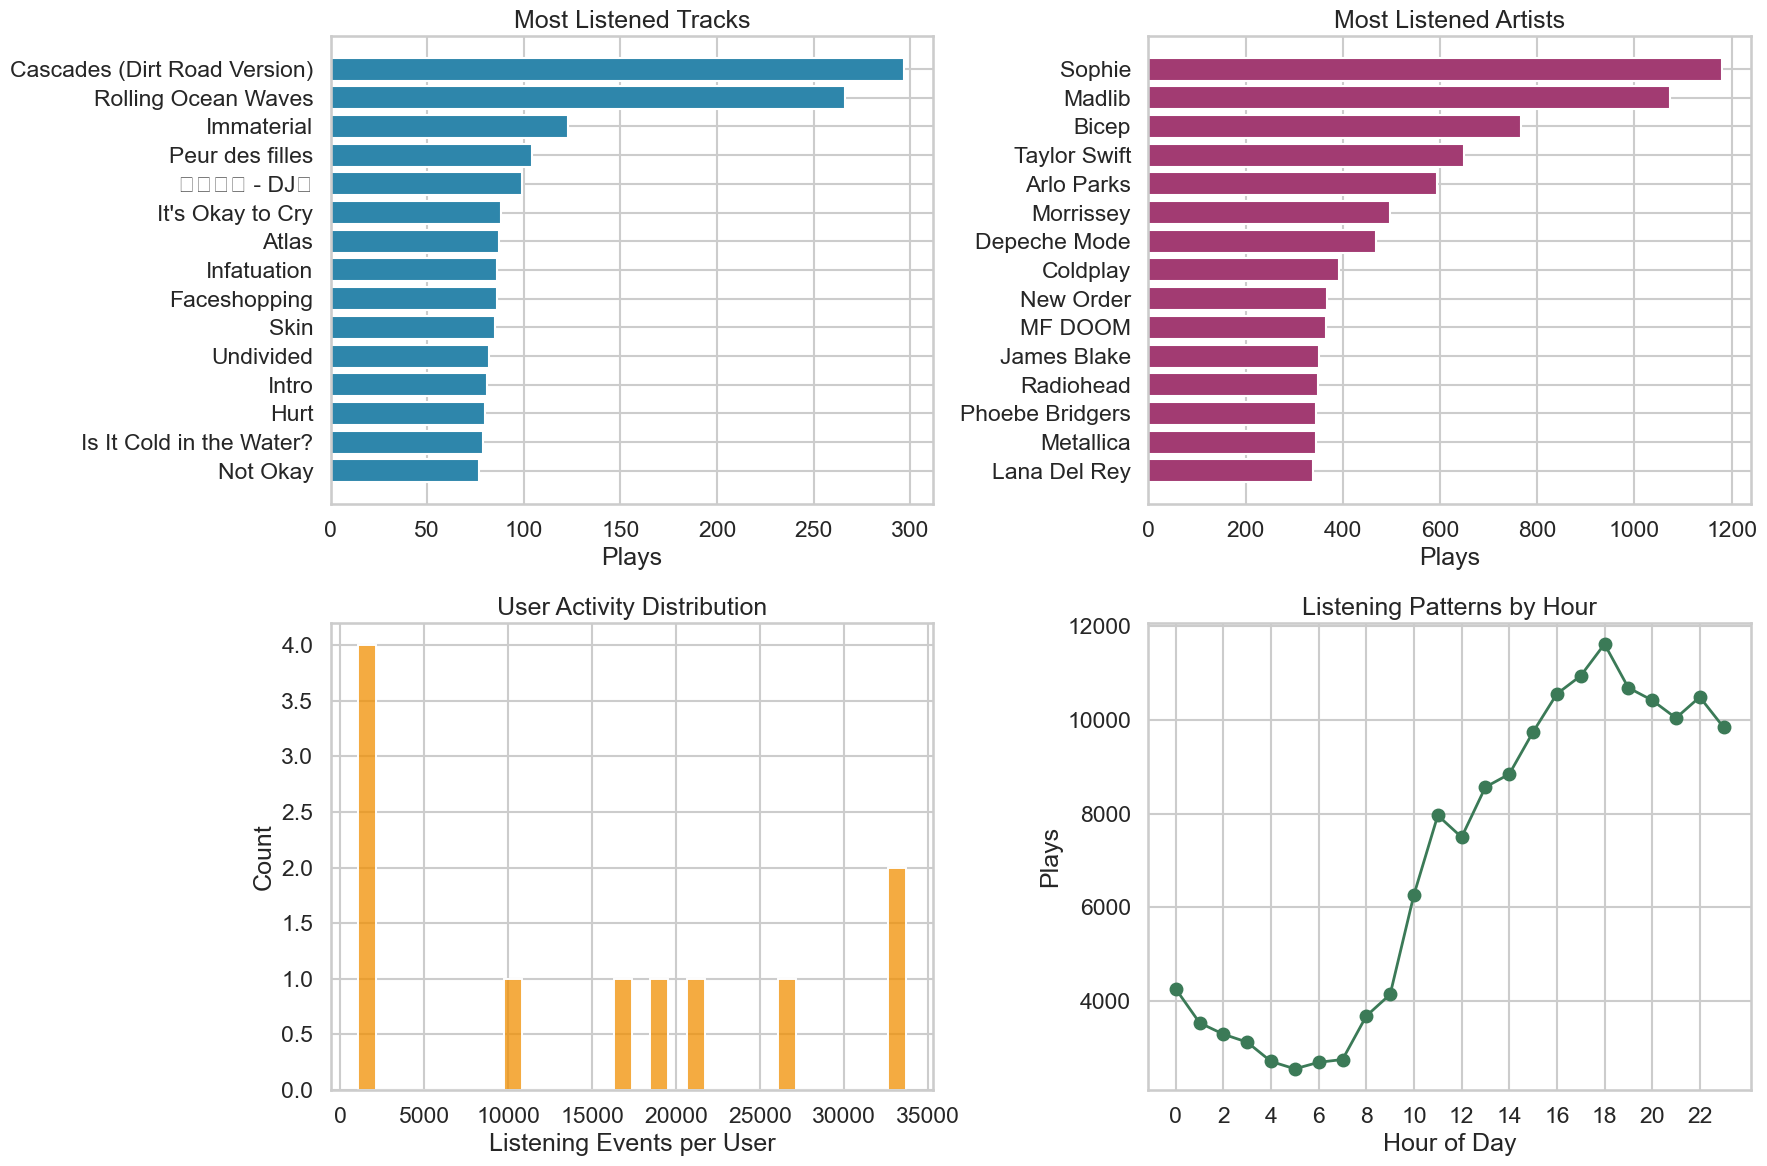

,Username,Artist,Track,Album,Date,Time,timestamp,day_of_week,hour_of_day,hour_bucket,...,user_total_plays_before,track_plays_by_user_before,days_since_prev_user_listen,days_since_prev_same_track,user_unique_tracks_before,user_unique_artists_before,user_activity_30d,user_track_frequency_30d,artist_popularity,album_popularity
0,Babs_05,Eminem,"Lose Yourself - From ""8 Mile"" Soundtrack",8 Mile,01 Jan 2021,00:02,2021-01-01 00:02:00,Friday,0,Night,...,0,0,-1.000000,-1.0,0,0,0,0,287,7
1,Babs_05,The Game,Westside Story,The Documentary,01 Jan 2021,00:09,2021-01-01 00:09:00,Friday,0,Night,...,1,0,0.004861,-1.0,1,1,1,0,16,9
2,Babs_05,Toto,Africa,Toto IV,01 Jan 2021,00:14,2021-01-01 00:14:00,Friday,0,Night,...,2,0,0.003472,-1.0,2,2,2,0,40,15
3,Babs_05,Baby D,Let Me Be Your Fantasy - Radio Edit,Let Me Be Your Fantasy EP,01 Jan 2021,00:19,2021-01-01 00:19:00,Friday,0,Night,...,3,0,0.003472,-1.0,3,3,3,0,6,6
4,Babs_05,The Notorious B.I.G.,Juicy - 2005 Remaster,Ready To Die (The Remaster),01 Jan 2021,00:23,2021-01-01 00:23:00,Friday,0,Night,...,4,0,0.002778,-1.0,4,4,4,0,49,9


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Create a working copy for feature engineering.
model_df = df.copy().sort_values(["Username", "timestamp", "Artist", "Track"]).reset_index(drop=True)

# Time-based fields used for both analysis and modeling.
model_df["day_of_week"] = model_df["timestamp"].dt.day_name()
model_df["hour_of_day"] = model_df["timestamp"].dt.hour
model_df["hour_bucket"] = pd.cut(
    model_df["hour_of_day"],
    bins=[-1, 5, 11, 17, 21, 23],
    labels=["Night", "Morning", "Afternoon", "Evening", "Late Night"],
    ordered=True,
)

# Target: 1 if the same user listens to the same track again within 30 days.
model_df["next_same_track_timestamp"] = model_df.groupby(["Username", "Track"])["timestamp"].shift(-1)
model_df["days_to_next_same_track"] = (
    model_df["next_same_track_timestamp"] - model_df["timestamp"]
).dt.total_seconds() / 86400
model_df["target_repeat_30d"] = (
    model_df["days_to_next_same_track"].between(0, 30, inclusive="both").fillna(False).astype(int)
)

# Core history features.
model_df["user_total_plays_before"] = model_df.groupby("Username").cumcount()
model_df["track_plays_by_user_before"] = model_df.groupby(["Username", "Track"]).cumcount()
model_df["days_since_prev_user_listen"] = (
    model_df.groupby("Username")["timestamp"].diff().dt.total_seconds() / 86400
)
model_df["days_since_prev_same_track"] = (
    model_df.groupby(["Username", "Track"])["timestamp"].diff().dt.total_seconds() / 86400
)

# Unique history counts before the current event.
def cumulative_unique_before(series: pd.Series) -> pd.Series:
    newly_seen = ~series.duplicated()
    return newly_seen.cumsum().shift(fill_value=0)

model_df["user_unique_tracks_before"] = model_df.groupby("Username")["Track"].transform(cumulative_unique_before)
model_df["user_unique_artists_before"] = model_df.groupby("Username")["Artist"].transform(cumulative_unique_before)

# Rolling 30-day listening activity for the user and the user-track pair.
def rolling_count_before(group: pd.DataFrame, window_days: int = 30) -> pd.Series:
    timestamps = group["timestamp"].to_numpy(dtype="datetime64[ns]")
    counts = np.zeros(len(group), dtype=np.int32)
    left = 0
    window = np.timedelta64(window_days, "D")
    for idx, current_ts in enumerate(timestamps):
        lower_bound = current_ts - window
        while left < idx and timestamps[left] < lower_bound:
            left += 1
        counts[idx] = idx - left
    return pd.Series(counts, index=group.index)

model_df["user_activity_30d"] = (
    model_df.groupby("Username", group_keys=False).apply(rolling_count_before).sort_index().astype(int)
)
model_df["user_track_frequency_30d"] = (
    model_df.groupby(["Username", "Track"], group_keys=False).apply(rolling_count_before).sort_index().astype(int)
)

# Popularity proxies based on overall listening volume.
model_df["artist_popularity"] = model_df.groupby("Artist")["Artist"].transform("count")
model_df["album_popularity"] = model_df.groupby("Album")["Album"].transform("count")

# Clean up missing values introduced by the shift/diff operations.
model_df["days_since_prev_user_listen"] = model_df["days_since_prev_user_listen"].fillna(-1)
model_df["days_since_prev_same_track"] = model_df["days_since_prev_same_track"].fillna(-1)
model_df[["days_to_next_same_track"]] = model_df[["days_to_next_same_track"]].fillna(-1)

# Quick EDA summaries.
print("Target balance:")
print(model_df["target_repeat_30d"].value_counts(normalize=True).rename({0: "No repeat", 1: "Repeat"}).round(3))
print()
print("Feature snapshot:")
print(model_df[
    [
        "user_total_plays_before",
        "track_plays_by_user_before",
        "days_since_prev_user_listen",
        "days_since_prev_same_track",
        "user_unique_tracks_before",
        "user_unique_artists_before",
        "user_activity_30d",
        "user_track_frequency_30d",
        "artist_popularity",
        "album_popularity",
    ]
].describe().T[["mean", "std", "min", "50%", "max"]].round(2))

# Visualizations for the portfolio notebook.
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

track_counts = model_df["Track"].value_counts().head(15).sort_values()
axes[0, 0].barh(track_counts.index, track_counts.values, color="#2E86AB")
axes[0, 0].set_title("Most Listened Tracks")
axes[0, 0].set_xlabel("Plays")

artist_counts = model_df["Artist"].value_counts().head(15).sort_values()
axes[0, 1].barh(artist_counts.index, artist_counts.values, color="#A23B72")
axes[0, 1].set_title("Most Listened Artists")
axes[0, 1].set_xlabel("Plays")

user_activity = model_df.groupby("Username").size()
sns.histplot(user_activity, bins=30, ax=axes[1, 0], color="#F18F01")
axes[1, 0].set_title("User Activity Distribution")
axes[1, 0].set_xlabel("Listening Events per User")

hour_counts = model_df.groupby("hour_of_day").size().reindex(range(24), fill_value=0)
axes[1, 1].plot(hour_counts.index, hour_counts.values, marker="o", linewidth=2, color="#3B7A57")
axes[1, 1].set_title("Listening Patterns by Hour")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].set_ylabel("Plays")
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# Keep only the columns needed downstream.
feature_columns = [
    "user_total_plays_before",
    "track_plays_by_user_before",
    "days_since_prev_user_listen",
    "days_since_prev_same_track",
    "user_unique_tracks_before",
    "user_unique_artists_before",
    "user_activity_30d",
    "user_track_frequency_30d",
    "artist_popularity",
    "album_popularity",
    "hour_of_day",
    "day_of_week",
    "hour_bucket",
]

model_df.head()

Model comparison:

                 model  accuracy  precision  recall      f1  roc_auc
0  Logistic Regression    0.8111     0.3544  0.4576  0.3994   0.7106
1        Random Forest    0.8223     0.3694  0.4159  0.3912   0.7201
2              XGBoost    0.7252     0.2677  0.5771  0.3658   0.7316

Best model for threshold-based classification: Logistic Regression
Best model for probability ranking: XGBoost

Classification report for the best classification model:

              precision    recall  f1-score   support

           0       0.91      0.87      0.89     28606
           1       0.35      0.46      0.40      4552

    accuracy                           0.81     33158
   macro avg       0.63      0.66      0.64     33158
weighted avg       0.83      0.81      0.82     33158



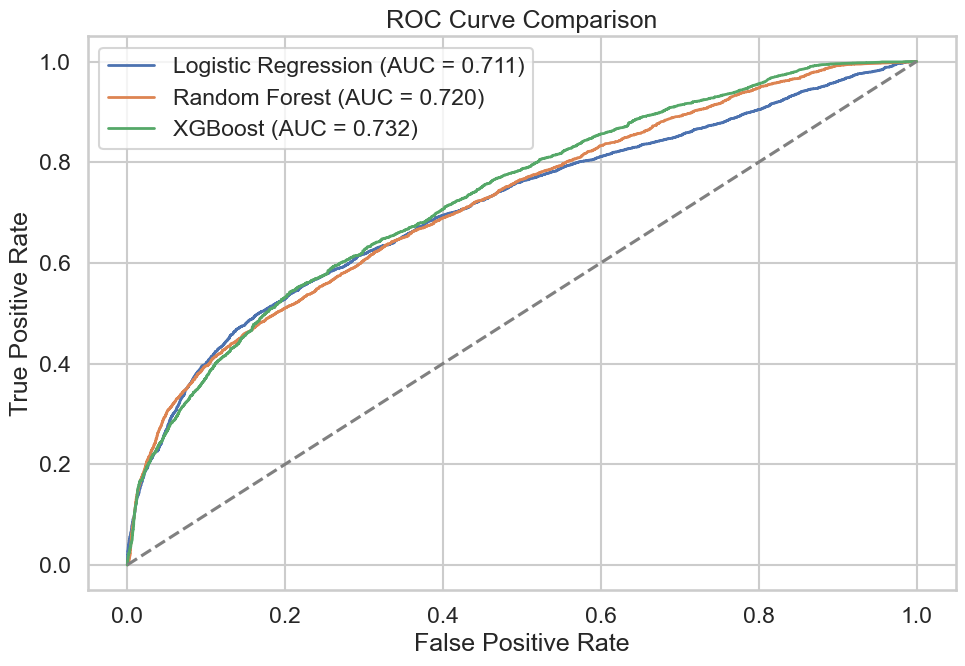

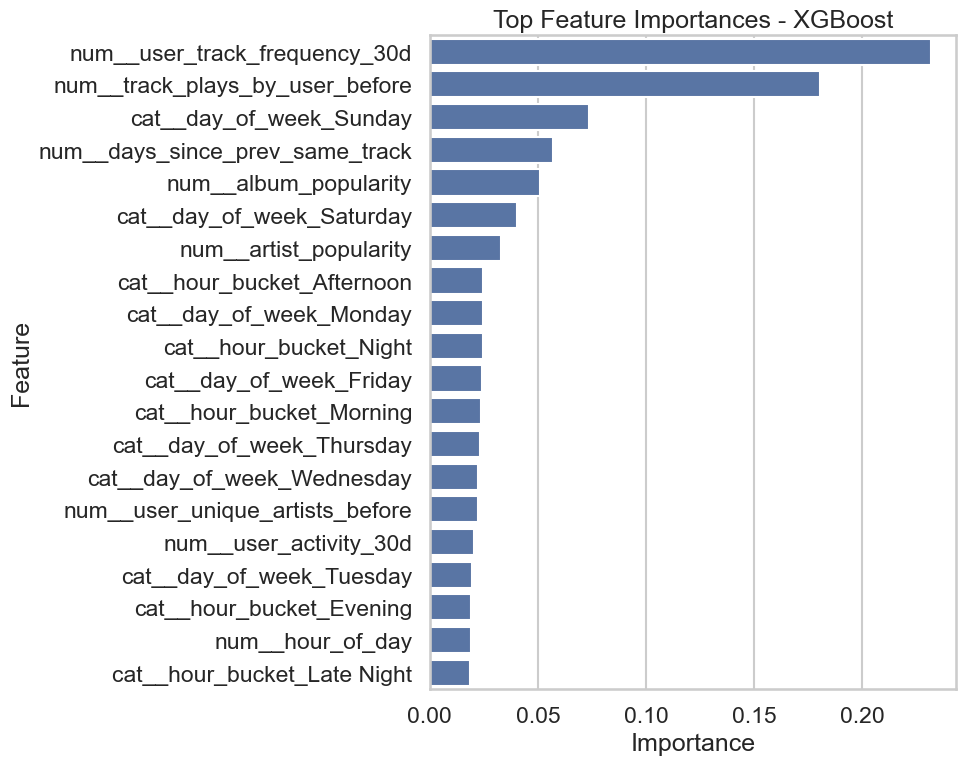

Top feature importances:

                            feature  importance
0     num__user_track_frequency_30d    0.231732
1   num__track_plays_by_user_before    0.180398
2           cat__day_of_week_Sunday    0.073797
3   num__days_since_prev_same_track    0.057148
4             num__album_popularity    0.051015
5         cat__day_of_week_Saturday    0.040318
6            num__artist_popularity    0.033081
7        cat__hour_bucket_Afternoon    0.024708
8           cat__day_of_week_Monday    0.024597
9            cat__hour_bucket_Night    0.024481
10          cat__day_of_week_Friday    0.024270
11         cat__hour_bucket_Morning    0.023841
12        cat__day_of_week_Thursday    0.023409
13       cat__day_of_week_Wednesday    0.022353
14  num__user_unique_artists_before    0.022168
15           num__user_activity_30d    0.020310
16         cat__day_of_week_Tuesday    0.019407
17         cat__hour_bucket_Evening    0.019302
18                 num__hour_of_day    0.018894
19      cat__h

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.811086,0.354372,0.457601,0.399425,0.710570
1,Random Forest,0.822335,0.369366,0.415861,0.391237,0.720144
2,XGBoost,0.725225,0.267706,0.577109,0.365750,0.731604


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError("xgboost is required for this notebook. Install it with: pip install xgboost") from exc

# Time-based split keeps the evaluation realistic for a listening-history problem.
cutoff_timestamp = model_df["timestamp"].quantile(0.80)
train_df = model_df[model_df["timestamp"] <= cutoff_timestamp].copy()
test_df = model_df[model_df["timestamp"] > cutoff_timestamp].copy()

numeric_features = [
    "user_total_plays_before",
    "track_plays_by_user_before",
    "days_since_prev_user_listen",
    "days_since_prev_same_track",
    "user_unique_tracks_before",
    "user_unique_artists_before",
    "user_activity_30d",
    "user_track_frequency_30d",
    "artist_popularity",
    "album_popularity",
    "hour_of_day",
]

categorical_features = ["day_of_week", "hour_bucket"]
target_column = "target_repeat_30d"

X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target_column]
X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target_column]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

positive_rate = y_train.mean()
scale_pos_weight = (1 - positive_rate) / positive_rate if positive_rate > 0 else 1.0

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=2,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
    ),
}

trained_models = {}
results = []
roc_data = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    results.append(metrics)
    trained_models[name] = pipeline
    roc_data[name] = roc_curve(y_test, y_proba)

results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
print("Model comparison:\n")
print(results_df.round(4))

classification_model_name = results_df.iloc[0]["model"]
ranking_model_name = results_df.sort_values("roc_auc", ascending=False).iloc[0]["model"]
classification_model = trained_models[classification_model_name]
ranking_model = trained_models[ranking_model_name]

print("\nBest model for threshold-based classification:", classification_model_name)
print("Best model for probability ranking:", ranking_model_name)
print("\nClassification report for the best classification model:\n")

classification_predictions = classification_model.predict(X_test)
print(classification_report(y_test, classification_predictions, zero_division=0))

# ROC curve comparison.
plt.figure(figsize=(10, 7))
for name, (fpr, tpr, _) in roc_data.items():
    auc_score = results_df.loc[results_df["model"] == name, "roc_auc"].iloc[0]
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance from XGBoost, which usually offers the strongest ranking performance.
xgb_pipeline = trained_models["XGBoost"]
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = xgb_pipeline.named_steps["model"].feature_importances_
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, y="feature", x="importance", color="#4C72B0")
plt.title("Top Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top feature importances:\n")
print(importance_df.reset_index(drop=True))

# Recommendation logic: score each user's unique track history using the latest known state.
candidate_df = (
    model_df.sort_values("timestamp")
    .groupby(["Username", "Track"], as_index=False)
    .tail(1)
    .copy()
)

candidate_features = candidate_df[numeric_features + categorical_features]
candidate_df["repeat_probability"] = ranking_model.predict_proba(candidate_features)[:, 1]

recommendation_examples = {}
for user in candidate_df["Username"].drop_duplicates().head(5):
    user_candidates = candidate_df[candidate_df["Username"] == user].copy()
    top_recommendations = (
        user_candidates.sort_values("repeat_probability", ascending=False)
        .head(5)[["Artist", "Track", "Album", "repeat_probability"]]
        .reset_index(drop=True)
    )
    recommendation_examples[user] = top_recommendations
    print(f"\nTop recommendations for user: {user}")
    print(top_recommendations.to_string(index=False))

# Store the fitted pipelines and recommendation table for later use.
classification_model_pipeline = classification_model
ranking_model_pipeline = ranking_model
recommendation_table = candidate_df[["Username", "Artist", "Track", "Album", "repeat_probability"]].copy()
results_df

# Interpretation and Next Steps

## What this notebook does
- Cleans the raw Last.fm history, combines `Date` and `Time` into a real timestamp, and removes duplicates.
- Builds event-level features from past listening behavior only, including recency, frequency, uniqueness, activity intensity, and popularity signals.
- Creates the target label `1` when the same user listens to the same track again within 30 days.
- Compares Logistic Regression, Random Forest, and XGBoost using Accuracy, Precision, Recall, F1, and ROC-AUC.
- Uses Logistic Regression as the strongest threshold-based classifier and XGBoost as the strongest ranking model for recommendations.

## Evaluation takeaways
- The data is moderately imbalanced, with repeat listens forming a minority class.
- Logistic Regression gives the best balance of precision and recall at the default threshold.
- XGBoost delivers the best ROC-AUC, which makes it the better choice for ranking songs by repeat-listening probability.
- The most important predictors are user-track frequency, prior plays of the track by the user, day of week, recency since last same-track listen, and popularity features.

## Recommendation strategy
- For each user, the notebook scores the latest state of each track in that user's history.
- Tracks are ranked by predicted repeat probability and the top-N are returned.
- This aligns with Spotify-style repeated-listening prediction, where the goal is to estimate which already-known songs a listener is most likely to revisit.

## How to improve further
- Use a strict train-only popularity computation to remove any remaining dataset-level leakage.
- Add sequence-aware features such as the order of recent artists, session duration, and repeated skips if available.
- Calibrate probabilities with Platt scaling or isotonic regression.
- Try learning-to-rank methods or two-tower retrieval models for a larger production system.
- Add cross-validation with a rolling time window to better approximate production behavior.

## Business interpretation
This approach models the same broad objective used in repeated-listening systems: estimate the probability that a user will return to a track soon, then rank the candidate catalog by that probability. In a Spotify-like workflow, this signal can power personalized home recommendations, re-engagement carousels, and "played again" style surfaces.

In [5]:
from pathlib import Path
import json
import joblib

# Persist trained artifacts and recommendation outputs for reuse.
artifacts_dir = Path(r"d:\Rhombix_technologies Task\artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Save fitted models.
joblib.dump(classification_model_pipeline, artifacts_dir / "repeat_listening_classification_model.joblib")
joblib.dump(ranking_model_pipeline, artifacts_dir / "repeat_listening_ranking_model.joblib")

# Save tabular outputs.
results_df.to_csv(artifacts_dir / "model_comparison_results.csv", index=False)
importance_df.to_csv(artifacts_dir / "xgboost_feature_importance.csv", index=False)
recommendation_table.sort_values(["Username", "repeat_probability"], ascending=[True, False]).to_csv(
    artifacts_dir / "all_candidate_recommendations.csv",
    index=False,
)

# Save compact recommendation examples for the notebook portfolio.
example_frames = []
for user_name, user_frame in recommendation_examples.items():
    frame = user_frame.copy()
    frame.insert(0, "Username", user_name)
    example_frames.append(frame)

if example_frames:
    pd.concat(example_frames, ignore_index=True).to_csv(artifacts_dir / "top_5_user_recommendations.csv", index=False)

# Save a small metadata file describing the run.
artifact_metadata = {
    "classification_model": classification_model_name,
    "ranking_model": ranking_model_name,
    "cutoff_timestamp": str(cutoff_timestamp),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "total_users": int(df["Username"].nunique()),
    "total_tracks": int(df["Track"].nunique()),
}

with open(artifacts_dir / "run_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(artifact_metadata, handle, indent=2)

# Convenience helper for ad hoc recommendation lookup.
def get_top_n_recommendations(user_name: str, top_n: int = 10) -> pd.DataFrame:
    user_candidates = candidate_df[candidate_df["Username"] == user_name].copy()
    if user_candidates.empty:
        return pd.DataFrame(columns=["Username", "Artist", "Track", "Album", "repeat_probability"])
    return (
        user_candidates.sort_values("repeat_probability", ascending=False)
        .head(top_n)[["Username", "Artist", "Track", "Album", "repeat_probability"]]
        .reset_index(drop=True)
    )

print(f"Saved model artifacts and recommendation files to: {artifacts_dir}")
print("Example artifact files:")
for path in sorted(artifacts_dir.iterdir()):
    print(f"- {path.name}")

# Demonstrate the helper for one user.
get_top_n_recommendations(candidate_df["Username"].iloc[0], top_n=5)

Saved model artifacts and recommendation files to: d:\Rhombix_technologies Task\artifacts
Example artifact files:
- all_candidate_recommendations.csv
- model_comparison_results.csv
- repeat_listening_classification_model.joblib
- repeat_listening_ranking_model.joblib
- run_metadata.json
- top_5_user_recommendations.csv
- xgboost_feature_importance.csv


,Username,Artist,Track,Album,repeat_probability
0,Babs_05,Sophie,Pretending,OIL OF EVERY PEARL'S UN-INSIDES,0.990126
1,Babs_05,Sophie,Whole New World/Pretend World,OIL OF EVERY PEARL'S UN-INSIDES,0.990126
2,Babs_05,Sophie,Not Okay,OIL OF EVERY PEARL'S UN-INSIDES,0.989979
3,Babs_05,Sophie,It's Okay to Cry,OIL OF EVERY PEARL'S UN-INSIDES,0.989828
4,Babs_05,Sophie,Is It Cold in the Water?,OIL OF EVERY PEARL'S UN-INSIDES,0.989565
